# T11a — RNN (Vanilla Recurrent Neural Network)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** Vanilla RNN → known to suffer from vanishing gradients on long sequences.

In [ ]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


## 1. Load data & build windows

In [3]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

# Engine-level train/val split (no leakage)
X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)

# Test windows (last window per engine)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (42725, 30, 48)  X_val: (50, 30, 48)
Train batches: 334  Val batches: 1


## 2. Model definition

Vanilla RNN — simplest recurrent architecture. Susceptible to vanishing gradients for long sequences.

In [ ]:
from src.models.dl_architectures import RNNModel


## 3. Train

In [5]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "RNN",
)


  [RNN] Epoch  10 | train=5.8634 | val=0.6821 | best=0.6821  [NASALoss]
  [RNN] Epoch  20 | train=3.6212 | val=3.6557 | best=0.6821  [NASALoss]
  [RNN] Early stop at epoch 20


## 4. Evaluate

In [6]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="RNN")
print(results)


  [RNN] RMSE: 17.4189  |  NASA Score: 1023.97 (mean: 4.13)  |  R2: 0.8358  |  Bias: -7.43 (early ↓)
{'rmse': 17.418851852416992, 'nasa_score': 1023.972412109375, 'nasa_score_mean': 4.12892101657006, 'r2_score': 0.8357584476470947, 'bias': -7.429942607879639}


## 5. Plots

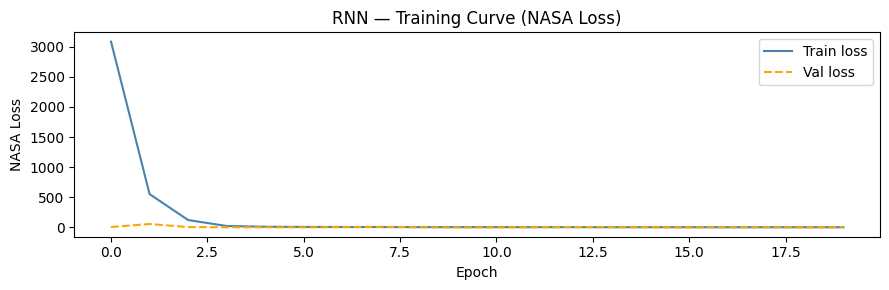

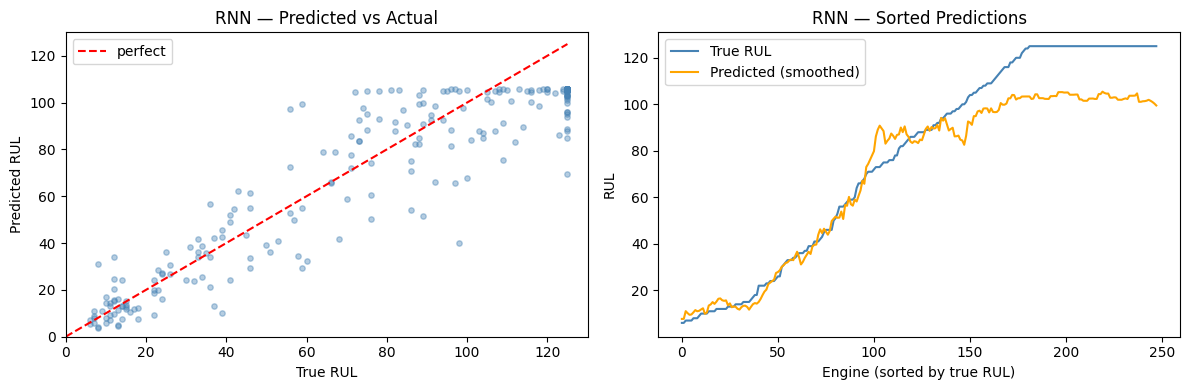

In [7]:
plot_loss_curves(train_losses, val_losses, model_name="RNN")
plot_predictions(y_true, y_pred, model_name="RNN")
